In [1]:
import sys
import os
from os.path import join
import glob
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display, clear_output

sys.path.insert(0, "/home/2649/repos/ABC-SN/code")
import abcsn_config
import abcsn_training
import data_degrading as dg
import data_plotting as dplt
import data_preparation as dp
import preprocessing

sys.path.insert(0, "/home/2649/repos/spec_res/code")
import review_spectrum as rs
import spectral_features as sf
import measure_signal as ms

from icecream import ic
from importlib import reload

reload(rs)
reload(sf)

REPO_DIR = "/home/2649/repos/spec_res"
DATA_DIR = join(REPO_DIR, "data")
BIANCO_DENOISING_DIR = join(DATA_DIR, "original_resolution_parquet/bianco_denoising")

Matplotlib is building the font cache; this may take a moment.
2026-02-20 15:13:33.540672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-20 15:13:33.911927: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-20 15:13:34.048073: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 15:13:35.102573: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compil

In [2]:
df_data, df_metadata, wvl = rs.load_sn_data()
FFTd_S_data, FFTd_S_metadata, FFTd_N_data, FFTd_N_metadata = rs.load_FFTdenoised_data()
# df_SNRmetadata = rs.create_SNRmetadata_file()

2026-02-20 15:18:21,620 Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-02-20 15:18:21,625 Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-02-20 15:18:21,631 findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-02-20 15:18:21,632 findfont: score(FontEntry(fname='/lustre/lrspec/users/2649/miniconda3/envs/fox/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Bold.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-02-20 15:18:21,633 findfont: score(FontEntry(fname='/lustre/lrspec/users/2649/miniconda3/envs/fox/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-02-20 15:18:21,633 findfont: score(FontEntry(fname='/lustre/lrspec/users/2649

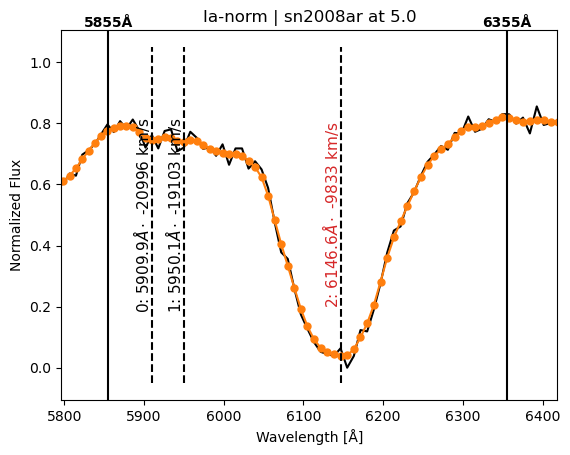

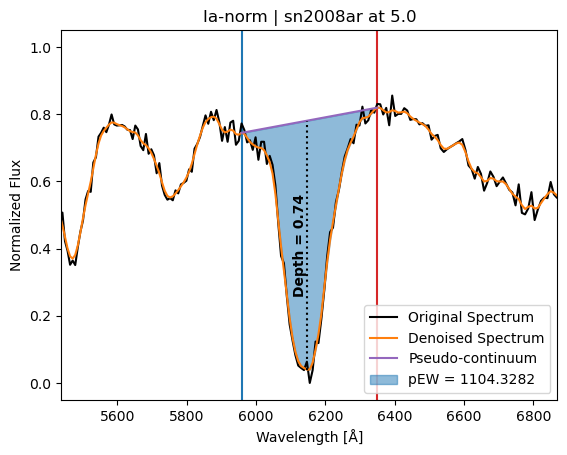

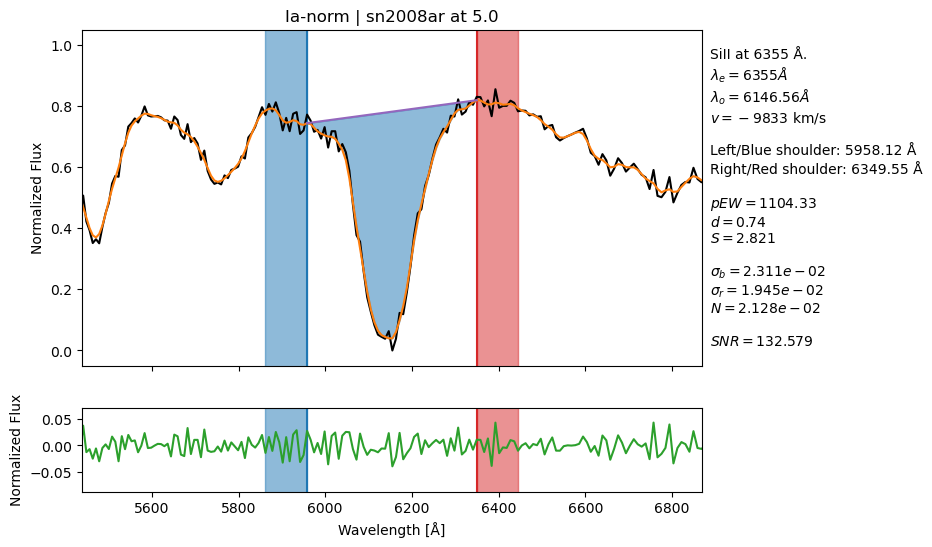

In [3]:
reload(ms)
i = 11
specsnr = ms.SpectrumSNR(
    df_metadata["SN Name"][i],
    df_metadata["SN Subtype"][i],
    df_metadata["Spectral Phase"][i],
    wvl,
    deepcopy(df_data.loc[i].values)
)
specsnr.minmax_normalize()
specsnr.set_spectral_feature()
specsnr.denoise_gaussian(10)
specsnr.find_spectral_line(feature_search_bounds=(500, 0), plot=True)
specsnr.find_spectral_shoulders(plot=False)
specsnr.calc_pEW(plot=True)
specsnr.measure_feature_noise(plot=False)
specsnr.measure_SNR(plot=True)

In [70]:
# rs.create_SNRmetadata_file()
df_SNRmetadata = rs.load_SNRmetadata()
sort_cols = ["SN Subtype", "SN Name", "Spectral Phase"]
df_SNRmetadata_sorted = df_SNRmetadata.sort_values(sort_cols).copy(deep=True)
df_SNRmetadata_sorted.head(20)

,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,minima_i,searchBlu,searchRed,useBlu,useRed,maxBlu,maxRed,noiseWindowBlu,noiseWindowRed
1284,sn00cp,Ia-norm,0,Ia,0,3.212,10.0,NaN,500.0,0.0,False,True,0.0,0.0,100.0,100.0
852,sn00cu,Ia-norm,0,Ia,0,8.955,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
853,sn00cu,Ia-norm,0,Ia,0,38.249,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
1067,sn00cw,Ia-norm,0,Ia,0,5.005,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
2842,sn00dg,Ia-norm,0,Ia,0,-4.998,10.0,NaN,500.0,0.0,False,True,0.0,0.0,100.0,100.0
2841,sn00dg,Ia-norm,0,Ia,0,4.755,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
1899,sn00dk,Ia-norm,0,Ia,0,1.355,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
1900,sn00dk,Ia-norm,0,Ia,0,11.192,10.0,NaN,500.0,0.0,True,True,1.0,0.0,100.0,100.0
1901,sn00dk,Ia-norm,0,Ia,0,28.759,10.0,NaN,500.0,0.0,True,True,0.0,0.0,100.0,100.0
1902,sn00dk,Ia-norm,0,Ia,0,36.679,10.0,2.0,500.0,0.0,True,True,0.0,0.0,100.0,100.0


In [54]:
np.isnan(df_SNRmetadata_sorted.loc[0, "Denoising Parameter"])

True

2. Be able to specify no smoothing.
3. When going to an index that has been written already to SNRmetadata, load the options used and display them

2026-02-14 22:10:56,212 Using the SiII feature at 6355Å.
2026-02-14 22:10:56,281 Searching for a local minimum in the spectrum between 5855 and 6355...
2026-02-14 22:10:56,282 One minimum found at 6129.940Å giving a line velocity of -10617km/s.


Writing to ../data/forSNR/SNRmetadata.parquet...
Ia-norm | sn00dm | 8.183 | index: 11


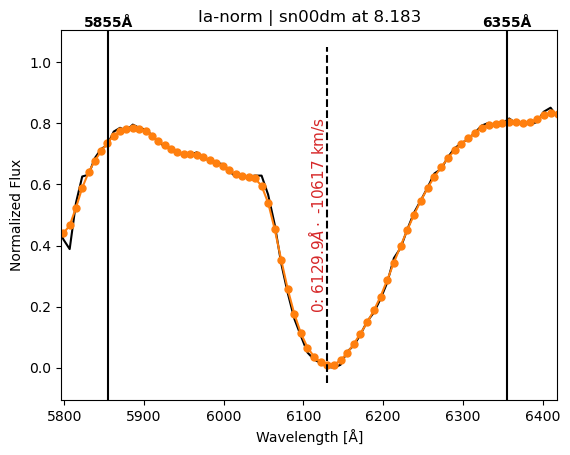

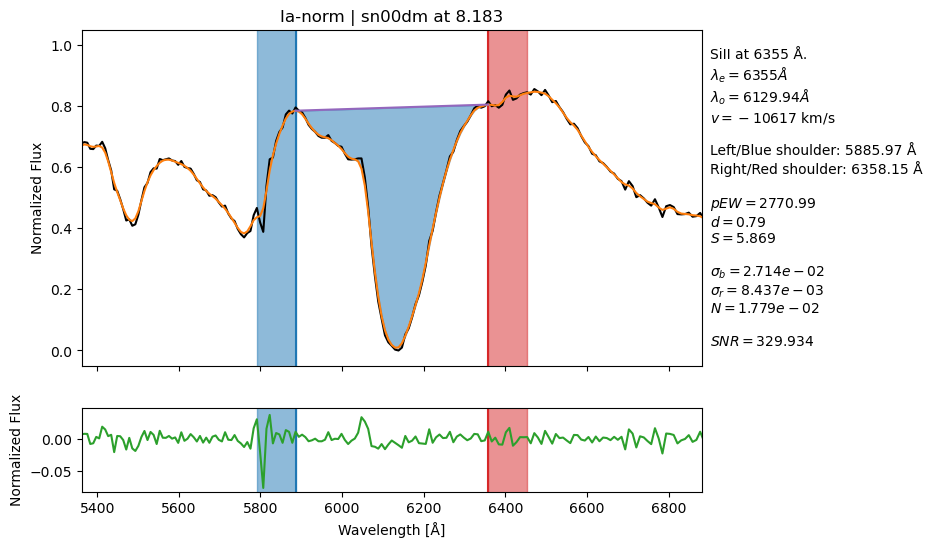

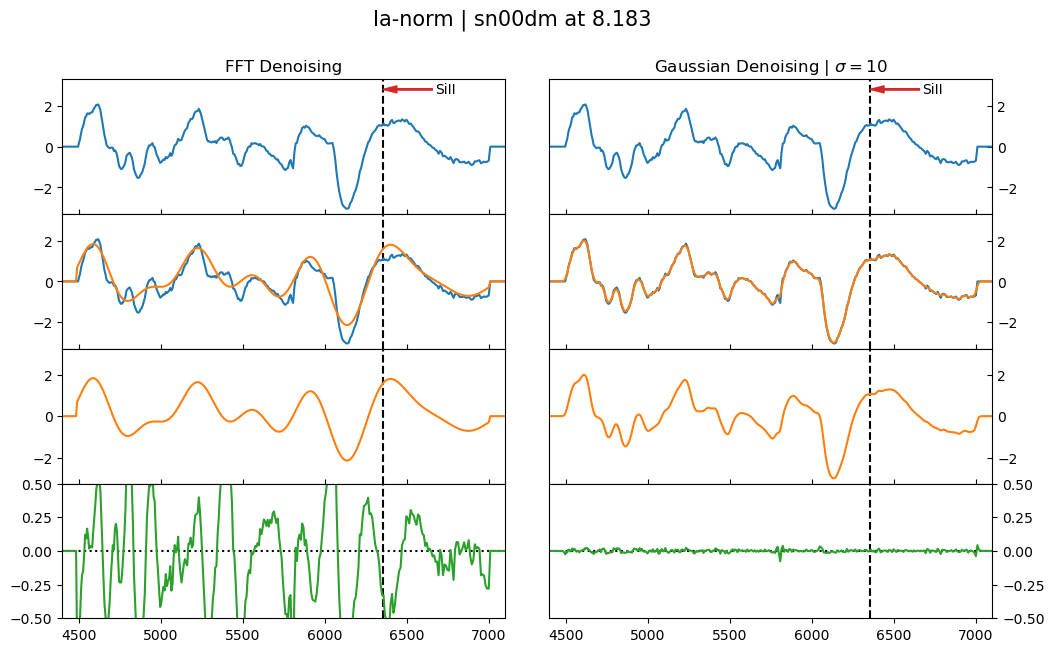

Ia-norm | sn00dm | 8.183 | index: 11


KeyboardInterrupt: Interrupted by user

Error in callback <function _draw_all_if_interactive at 0x2ad354c87940> (for post_execute):


KeyboardInterrupt: 

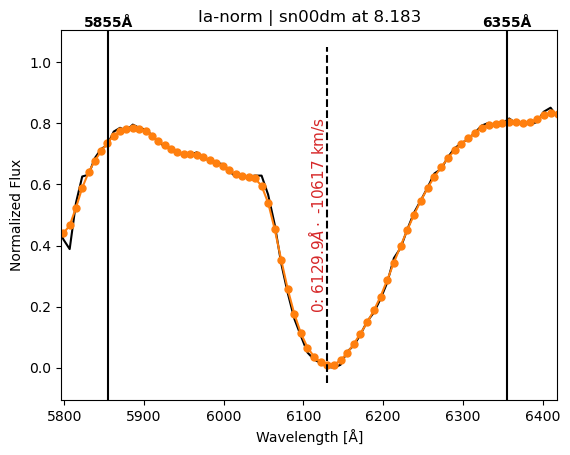

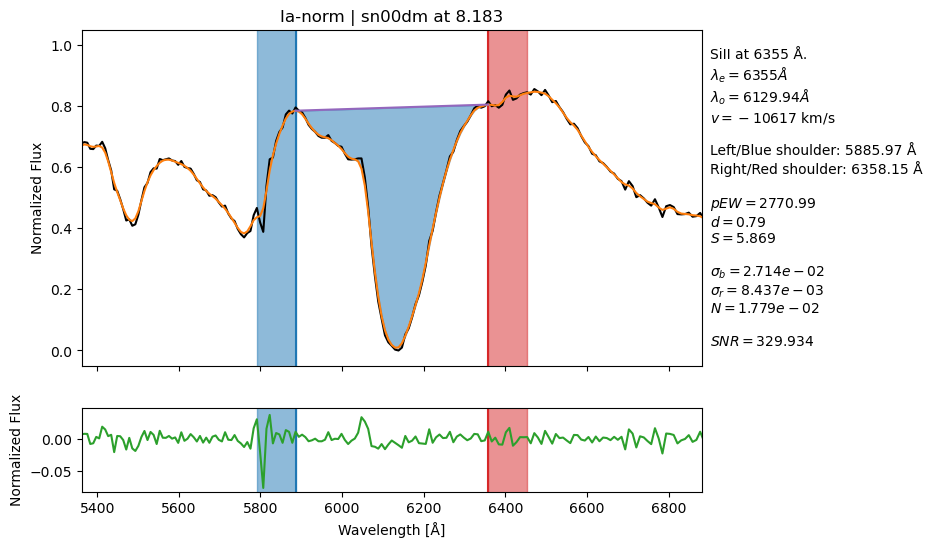

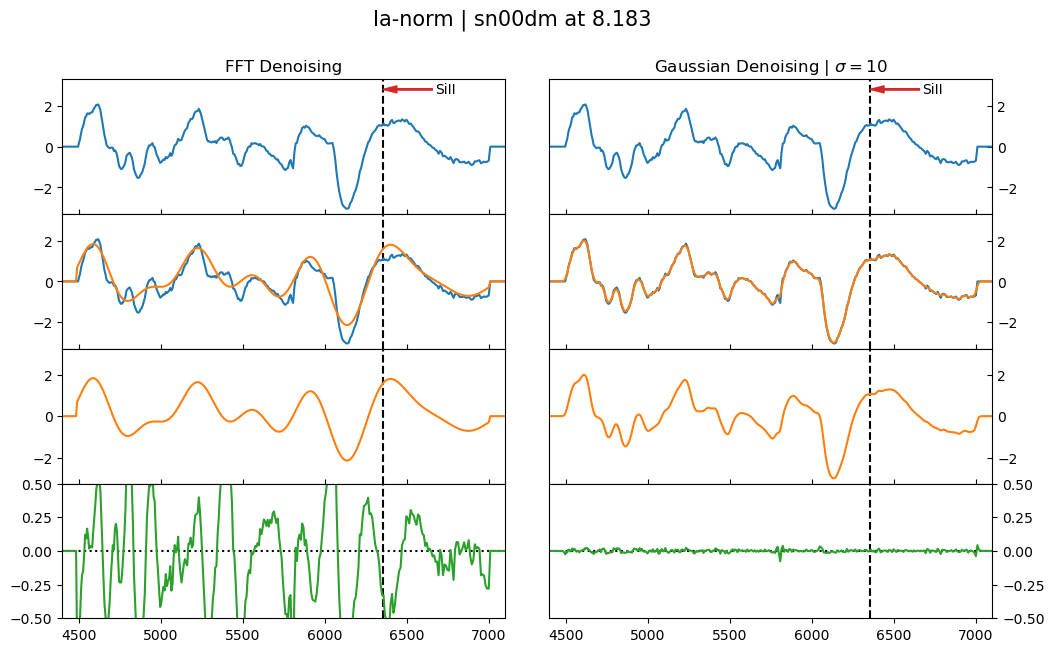

In [68]:
reload(rs)
reload(ms)
rs.review(i=0)

In [ ]:
# file_bianco_denoising_signal = os.path.join(BIANCO_DENOISING_DIR, "signal/preprocessed_signal_only.parquet")
# file_bianco_denoising_noise = os.path.join(BIANCO_DENOISING_DIR, "noise/preprocessed_noise_only.parquet")
# df_bianco_denoising_signal = pd.read_parquet(file_bianco_denoising_signal)
# df_bianco_denoising_noise = pd.read_parquet(file_bianco_denoising_noise)

# df_data = pd.read_parquet(os.path.join(DATA_DIR, "original_resolution_parquet/df_preprocessed.parquet"))

In [ ]:
# # 0: index
# # 1: wvl
# # 2: flux_columns
# # 3: metadata_columns
# # 4: df_fluxes
# # 5: df_metadata
# # 6: data
# df_preprocessed_extraction = dp.extract_dataframe(df_preprocessed)

# flux_columns = df_preprocessed_extraction[2]
# df_preprocessed_fluxes = df_preprocessed_extraction[4].copy(deep=True)

# wvl = df_preprocessed_extraction[1]
# sn_names = df_preprocessed_extraction[0]
# sn_phases = df_preprocessed_extraction[5]["Spectral Phase"]
# sn_types = df_preprocessed_extraction[5]["SN Subtype"]
# fluxes = df_preprocessed_extraction[6]

In [ ]:
# file_preprocessed_metadata = os.path.join(DATA_DIR, "original_resolution_parquet/df_preprocessed_metadata_only.parquet")

# # df_preprocessed_metadata = df_preprocessed_extraction[5].copy(deep=True)
# # df_preprocessed_metadata["Denoising Parameter"] = np.nan
# # df_preprocessed_metadata.to_parquet(file_preprocessed_metadata)

# df_preprocessed_metadata = pd.read_parquet(file_preprocessed_metadata)
# df_preprocessed_metadata.info()

In [ ]:
# def gaussian(x, mu, sd):
#     coeff = 1 / (sd * np.sqrt(2 * np.pi))
#     g = coeff * np.exp(-(x - mu)**2 / (2 * sd**2))
#     return g


# def gaussian_smoothing(spec, sd):
#     N = len(spec)
#     f = gaussian(np.arange(N), N/2, sd)
#     return np.sum(spec * f)

In [ ]:
# lines = {
#     "Ia": ("SiII", 6355),
#     "Ib": ("HeI", 5876),
#     "Ic": ("FeII", 5169),
#     "II": (r"H$\alpha$", 6562)
# }


# def sync_ylim(ax1, ax2):
#     ylim_extreme = np.max(np.abs([*ax1.get_ylim(), *ax2.get_ylim()]))
#     ax1.set_ylim((-ylim_extreme, ylim_extreme))
#     ax2.set_ylim((-ylim_extreme, ylim_extreme))

#     ax1.tick_params(axis="x", which="both", direction="in")
#     ax2.tick_params(axis="x", which="both", direction="in")

#     ax2.tick_params(axis="y", which="both", direction="in")
#     ax2.yaxis.tick_right()
    
#     return


# def plot_one_spectrum(
#     sn_name,
#     sn_phase,
#     sn_type,
#     wvl, 
#     original_flux, 
#     bianco_signal,
#     bianco_noise,
#     gaussian_signal,
#     guassian_noise,
#     sd,
# ):

#     fig, axes = plt.subplots(nrows=4, ncols=2, sharex=True, figsize=(12, 7))
#     fig.subplots_adjust(hspace=0, wspace=0.1)
#     axes[0, 0].set_xlim((4400, 7100))

#     fig.suptitle(f"{sn_type} | {sn_name} at {sn_phase}", fontsize=15)

#     c_original_flux = "tab:blue"
#     c_signal = "tab:orange"
#     c_noise = "tab:green"

#     feature_name, feature_location = lines[sn_type[:2]]
#     [ax.axvline(x=feature_location, c="k", ls="--") for ax in axes.ravel()]

#     axes[0, 0].set_title("Bianco Denoising")
#     axes[0, 1].set_title(rf"Gaussian Denoising | $\sigma={sd}$")
    
#     axes[0, 0].plot(wvl, original_flux, c=c_original_flux)
#     axes[0, 1].plot(wvl, original_flux, c=c_original_flux)
    
#     axes[1, 0].plot(wvl, original_flux, c=c_original_flux)
#     axes[1, 1].plot(wvl, original_flux, c=c_original_flux)
    
#     axes[1, 0].plot(wvl, bianco_signal, c=c_signal)
#     axes[1, 1].plot(wvl, gaussian_signal, c=c_signal)

#     axes[2, 0].plot(wvl, bianco_signal, c=c_signal)
#     axes[2, 1].plot(wvl, gaussian_signal, c=c_signal)
    
#     axes[3, 0].axhline(y=0, c="k", ls=":")
#     axes[3, 1].axhline(y=0, c="k", ls=":")
#     axes[3, 0].plot(wvl, bianco_noise, c=c_noise)
#     axes[3, 1].plot(wvl, gaussian_noise, c=c_noise)

#     sync_ylim(axes[0, 0], axes[0, 1])
#     sync_ylim(axes[1, 0], axes[1, 1])
#     sync_ylim(axes[2, 0], axes[2, 1])
#     sync_ylim(axes[3, 0], axes[3, 1])

#     axes[0, 0].annotate(
#         feature_name,
#         (feature_location, axes[0, 0].get_ylim()[1]*0.85),
#         xytext=(feature_location*1.05, axes[0, 0].get_ylim()[1]*0.85),
#         va="center",
#         arrowprops={
#             "width": 1,
#             "headwidth": 5,
#             "headlength": 10,
#             "color": "tab:red"
#         }
#     )

#     axes[0, 1].annotate(
#         feature_name,
#         (feature_location, axes[0, 1].get_ylim()[1]*0.85),
#         xytext=(feature_location*1.05, axes[0, 1].get_ylim()[1]*0.85),
#         va="center",
#         arrowprops={
#             "width": 1,
#             "headwidth": 5,
#             "headlength": 10,
#             "color": "tab:red"
#         }
#     )

#     fig.show()
#     return fig

In [ ]:
# i = 1426
# user_input = None

# while i <= sn_names.size:
#     sn_name = sn_names[i]
#     sn_phase = sn_phases.iloc[i]
#     sn_type = sn_types.iloc[i]
#     original_flux = fluxes[i]
#     print(f"{sn_type} | {sn_name} | {sn_phase} | index: {i}")

#     if isinstance(user_input, float):
#         sd = user_input
#     else:
#         sd = 2.0

#     # if sn_type in ["Ia-csm",  "Ia-pec", "Ib-pec", "Ic-pec", "IIL", "IIn", "II-pec"]:
#     #     i += 1
#     #     continue

#     # Some spectra failed to be denoised with the Bianco method, so they are not present in the dataframes.
#     # This block catches these cases and plots 0 for the signal and noise so that the spectrum can still be reviewed.
#     try:
#         index_signal = df_bianco_denoising_signal.index == sn_name
#         index_signal &= df_bianco_denoising_signal["Spectral Phase"] == sn_phase
#         bianco_signal = df_bianco_denoising_signal[index_signal][df_preprocessed_extraction[2]].values[0]
    
#         index_noise = df_bianco_denoising_noise.index == sn_name
#         index_noise &= df_bianco_denoising_noise["Spectral Phase"] == sn_phase
#         bianco_noise = df_bianco_denoising_noise[index_noise][df_preprocessed_extraction[2]].values[0]
#     except IndexError:
#         print(f"Supernova '{sn_name}' at phase {sn_phase} does not have a Bianco-denoised sample.")
#         bianco_signal = [0] * wvl.size
#         bianco_noise = [0] * wvl.size

#     # Perform the Gaussian smoothing to extract the spectrum signal.
#     # Then, subtract the signal from the original spectrum to get the noise.
#     assert np.all(original_flux == df_preprocessed_fluxes.iloc[i].values)
#     gaussian_signal = df_preprocessed_fluxes.iloc[i:i+1].T.rolling(
#         window=100,
#         center=True,
#         closed="both",
#         min_periods=0).apply(gaussian_smoothing, args=(sd,)).T.values[0, :]
#     gaussian_noise = original_flux - gaussian_signal
    
#     fig = plot_one_spectrum(
#         sn_name,
#         sn_phase,
#         sn_type,
#         wvl,
#         original_flux,
#         bianco_signal,
#         bianco_noise,
#         gaussian_signal,
#         gaussian_noise,
#         sd,
#     )
#     display(plt.gcf())

#     metadata_index = (df_preprocessed_metadata.index == sn_name)
#     metadata_index &= (df_preprocessed_metadata["Spectral Phase"] == sn_phase)
#     print(f"Currently saved denoising parameter: {df_preprocessed_metadata.loc[metadata_index, 'Denoising Parameter'].values[0]}")
#     user_input = input("New stddev: ").lower()

#     # If the user enters something that can be converted to a float, do not increment the loop counter, i.
#     # Upon the next loop, the Gaussian denoising will use that float as the new stddev for the same spectrum.
#     # If the user enters something that cannot be converted to a float, then either we are satisified with the current stddev,
#     # or we want to use the Bianco smoothing.
#     try:
#         user_input = float(user_input)
#     except ValueError:
        
#         if (user_input == "b") or (user_input == "bianco"):
#             i += 1
#             df_preprocessed_metadata.loc[metadata_index, "Denoising Parameter"] = -1
#             df_preprocessed_metadata.to_parquet(file_preprocessed_metadata)
        
#         elif (user_input == "p") or (user_input == "previous"):
#             i -= 1

#         elif (user_input == "n") or (user_input == "next"):
#             i += 1

#         elif user_input[:4] == "goto":
#             i = int(user_input.split(" ")[1])

#         elif user_input == "":
#             i += 1
#             df_preprocessed_metadata.loc[metadata_index, "Denoising Parameter"] = sd
#             df_preprocessed_metadata.to_parquet(file_preprocessed_metadata)

#         else:
#             print("Non-valid input.")
#             continue
        
#         user_input = None

#     clear_output(wait=True)
#     plt.close()
    